# House Price Prediction: Neural Network

This notebook explores the application of a **feedforward neural network** to the housing dataset. The goal is to predict house prices and evaluate whether
a deep learning approach can outperform classical regression methods on a small tabular dataset.

As a reference point, a tuned Lasso regression (α=0.000762) with applied splines (`HouseAge` and `TotalBsmtSF`) from the [previous project](https://github.com/alexandrabaturina/house-price-prediction/blob/main/02_nonlinear_modeling/nonlinear_modeling.ipynb) is used as a baseline. It achieved a validation RMSE of 0.1150 with a train/validation gap of 0.0107, indicating strong generalization.

| Model | Train RMSE | Validation RMSE | Gap |
|---|---|---|---|
| Lasso + Splines (α=0.000762) | 0.1043 | 0.1150 | 0.0107 |

The cleaned datasets and preprocessing pipelines from the linear models project are reused directly.

The data preparation follows the same pipeline as in the linear models project:

* Data Preprocessing
* Encode Categorical Variables
* Scale Numerical Features
* Transform the Target Variable (log1p)
* Split the Data

The proposed architecture follows a pyramidal structure with decreasing layer sizes (**128 → 64 → 32**):

- Input layer: number of input features
- Dense layer: 128 neurons, ReLU
- Dropout: 0.3
- Dense layer: 64 neurons, ReLU
- Dropout: 0.2
- Dense layer: 32 neurons, ReLU
- Output layer: 1 neuron

Training is performed using the **Adam optimizer** with **early stopping**.

> **Note on reproducibility:**
> 
> Due to the stochastic nature of neural network training (random weight initialization, dropout, batch sampling), results may vary between runs even with fixed seeds. This instability is itself a meaningful observation — unlike Lasso regression, which always produces the same result, the neural network's performance is sensitive to randomness. All reported results correspond to a single fixed run.

In [1]:
BASELINE_LASSO_RESULTS = {
    'Train RMSE': 0.1043,
    'Validation RMSE': 0.1150,
    'Gap': 0.0107
}

In [2]:
import csv
import joblib
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from pathlib import Path

# Cleaned datasets from the linear models project are used directly
# Raw data preprocessing is documented in 01_linear_models/house_price_modeling.ipynb

ROOT = Path.cwd().parent
CLEAN_TRAIN_DATA_PATH = ROOT / 'data' / 'processed' / 'train_clean.csv'
CLEAN_TEST_DATA_PATH = ROOT/ 'data' / 'processed' / 'test_clean.csv'

In [4]:
df_train = pd.read_csv(CLEAN_TRAIN_DATA_PATH)
df_train.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,SaleType,SaleCondition,SalePrice,HouseAge
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,WD,Normal,208500,5
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,WD,Normal,181500,31
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,WD,Normal,223500,7
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,WD,Abnorml,140000,91
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,WD,Normal,250000,8


In [5]:
df_test = pd.read_csv(CLEAN_TEST_DATA_PATH)
df_test.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,SaleType,SaleCondition,HouseAge
0,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,...,120,0,NaN,MnPrv,NaN,0,6,WD,Normal,49
1,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,0,NaN,NaN,Gar2,12500,6,WD,Normal,52
2,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,0,NaN,MnPrv,NaN,0,3,WD,Normal,13
3,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,6,WD,Normal,12
4,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,...,144,0,NaN,NaN,NaN,0,1,WD,Normal,18


### Preprocessing Pipelines

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [7]:
ARTIFACTS_PATH = ROOT / 'artifacts'

# Load pipeline components
numeric_median_pipeline = joblib.load(ARTIFACTS_PATH / 'numeric_median_pipeline.pkl')
numeric_zero_pipeline = joblib.load(ARTIFACTS_PATH / 'numeric_zero_pipeline.pkl')
cat_no_feature_pipeline = joblib.load(ARTIFACTS_PATH / 'cat_no_feature_pipeline.pkl')
cat_truly_missing_pipeline = joblib.load(ARTIFACTS_PATH / 'cat_truly_missing_pipeline.pkl')
cat_no_missing_pipeline = joblib.load(ARTIFACTS_PATH / 'cat_no_missing_pipeline.pkl')

# Load column lists
with open(ARTIFACTS_PATH / 'column_lists.pkl', 'rb') as f:
    column_lists = pickle.load(f)

num_fill_with_zero = column_lists['num_fill_with_zero']
num_fill_with_median = column_lists['num_fill_with_median']
cat_no_feature = column_lists['cat_no_feature']
cat_truly_missing = column_lists['cat_truly_missing']
cat_no_missing = column_lists['cat_no_missing']
num_features = column_lists['num_features']

In [8]:
preprocessor = ColumnTransformer([
    ('numeric_median', numeric_median_pipeline, num_fill_with_median),
    ('numeric_zero', numeric_zero_pipeline, num_fill_with_zero),
    ('cat_no_feature', cat_no_feature_pipeline, cat_no_feature),
    ('cat_truly_missing',cat_truly_missing_pipeline, cat_truly_missing),
    ('cat_no_missing', cat_no_missing_pipeline, cat_no_missing),
])

## Default FeedForward Neural Network Model

In [9]:
import warnings
warnings.filterwarnings('ignore', message='TensorFlow GPU support is not available')

In [10]:
try:
    import tensorflow as tf
except ImportError:
    !pip install tensorflow
    import tensorflow as tf

from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [11]:
X = df_train.drop('SalePrice', axis=1)
y = np.log1p(df_train['SalePrice'])

In [12]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=123)

In [13]:
# UserWarning about unknown categories is expected when predicting on unseen data
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    
    X_train_processed = preprocessor.fit_transform(X_train)
    X_val_processed = preprocessor.transform(X_val)

In [14]:
np.random.seed(42)
tf.random.set_seed(42)

model = Sequential([
    Input(shape=(X_train_processed.shape[1],)),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(
    optimizer='adam', # default learning rate 0.001
    loss='mse',
    metrics=[tf.keras.metrics.RootMeanSquaredError(name='rmse')]
)

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        31,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,857 (163.50 KB)

 Trainable params: 41,857 (163.50 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history = model.fit(
    X_train_processed, y_train,
    validation_data=(X_val_processed, y_val),
    epochs=200,
    batch_size=32,
    callbacks=[EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)],
    verbose=1
)

print(f"Stopped at epoch: {len(history.history['val_loss'])}")

Epoch 1/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 71.2450 - rmse: 8.4407 - val_loss: 6.0706 - val_rmse: 2.4639
Epoch 2/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 5.1551 - rmse: 2.2705 - val_loss: 1.6388 - val_rmse: 1.2802
Epoch 3/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.0878 - rmse: 2.0218 - val_loss: 1.2029 - val_rmse: 1.0968
Epoch 4/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.3794 - rmse: 1.8383 - val_loss: 0.8238 - val_rmse: 0.9076
Epoch 5/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.1946 - rmse: 1.7873 - val_loss: 1.0452 - val_rmse: 1.0224
Epoch 6/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.9302 - rmse: 1.7118 - val_loss: 1.2414 - val_rmse: 1.1142
Epoch 7/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.7447 - rmse: 1.6567 - val_loss: 0.9888 - val_rmse: 0.9944
Epoch 8/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.4814 - rmse: 1.5752 - val_loss: 1.1070 - val_rmse: 1.0521
Epoch 9/200
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/

In [17]:
best_val_rmse_baseline = min(history.history['val_rmse'])
best_epoch = history.history['val_rmse'].index(best_val_rmse_baseline) + 1

print(f"Best validation RMSE: {best_val_rmse_baseline:.4f} at epoch {best_epoch}")

Best validation RMSE: 0.7211 at epoch 11


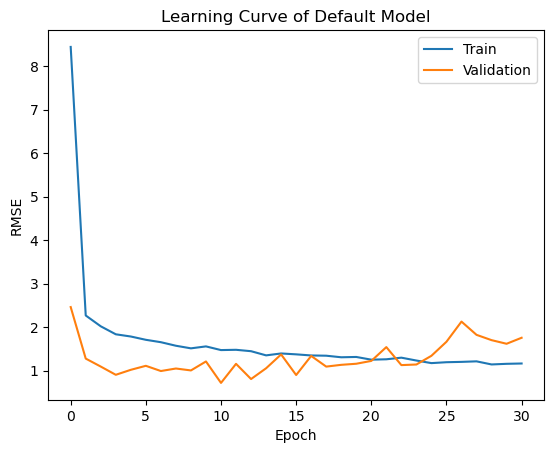

In [18]:
import matplotlib.pyplot as plt

plt.plot(history.history['rmse'],     label='Train')
plt.plot(history.history['val_rmse'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.title('Learning Curve of Default Model')
plt.legend()
plt.show()

The model shows clear signs of overfitting early in training: validation RMSE rises sharply while training RMSE continues to decrease. Early stopping halts training once no improvement is observed.

### Explore Sensitivity to Random Initialization

To quantify the effect of random initialization, the default model is trained five times with different fixed seeds.
    
These values were chosen arbitrarily. The goal is not to find the best seed, but to demonstrate the variance in performance across independent runs.

In [19]:
seeds = [42, 123, 456, 789, 1024]
scores = []

for seed in seeds:
    np.random.seed(seed)
    tf.random.set_seed(seed)
    
    model = Sequential([
        Input(shape=(X_train_processed.shape[1],)),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    
    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=[tf.keras.metrics.RootMeanSquaredError(name='rmse')]
    )
    
    model.fit(
        X_train_processed, y_train,
        validation_data=(X_val_processed, y_val),
        epochs=200,
        batch_size=32,
        callbacks=[EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)],
        verbose=0
    )
    
    best_val_rmse = min(model.history.history['val_rmse'])
    scores.append(best_val_rmse)
    print(f"val_rmse={best_val_rmse:.4f} for seed={seed}")

val_rmse=1.2128 for seed=42
val_rmse=0.7942 for seed=123
val_rmse=1.1234 for seed=456
val_rmse=1.0705 for seed=789
val_rmse=1.1415 for seed=1024


In [20]:
print(f"Min: {min(scores):.4f}")
print(f"Max: {max(scores):.4f}")
print(f"Mean: {np.mean(scores):.4f} ± {np.std(scores):.4f}")

Min: 0.7942
Max: 1.2128
Mean: 1.0685 ± 0.1445


The results show substantial variation across runs, with the best and worst seeds producing notably different validation RMSE values. 
    
This confirms that the model's performance is highly sensitive to random initialization.

## Random Search over Training Hyperparameters

A random search is performed over key training hyperparameters — learning rate, batch size, and early stopping patience — while keeping the architecture fixed (128 → 64 → 32). The goal is to find the best training configuration.

In [21]:
import random
from tensorflow.keras.callbacks import ReduceLROnPlateau

param_space = {
    'lr': [0.01, 0.001, 0.0001, 0.00005],
    'batch_size': [16, 32, 64],
    'patience': [10, 20, 30],
}

N_ITER = 15
results = []

for i in range(N_ITER):
    random.seed(i)
    params = {k: random.choice(v) for k, v in param_space.items()}
    
    np.random.seed(42)
    tf.random.set_seed(42)

    model = Sequential([
        Input(shape=(X_train_processed.shape[1], )),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])

    model.compile(
        optimizer=Adam(learning_rate=params['lr']),
        loss='mse',
        metrics=[tf.keras.metrics.RootMeanSquaredError(name='rmse')]
    )
    
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=params['patience'], restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.000001)
    ]
    
    history = model.fit(
        X_train_processed, y_train,
        validation_data=(X_val_processed, y_val),
        epochs=200,
        batch_size=params['batch_size'],
        callbacks=callbacks,
        verbose=0
    )
    
    best_val_rmse = min(history.history['val_rmse'])
    stopped_epoch = len(history.history['val_loss'])

    results.append({**params, 'val_rmse': best_val_rmse, 'epochs': stopped_epoch})
    
    print(f"[{i+1}/{N_ITER}] val_rmse={best_val_rmse:.4f} with: "
      f"{{lr={params['lr']}, batch_size={params['batch_size']}, patience={params['patience']}, epochs={stopped_epoch}}}")

results_df = pd.DataFrame(results).sort_values('val_rmse')

[1/15] val_rmse=1.1038 with: {lr=5e-05, batch_size=32, patience=10, epochs=90}
[2/15] val_rmse=0.8110 with: {lr=0.001, batch_size=64, patience=10, epochs=19}
[3/15] val_rmse=1.8301 with: {lr=0.01, batch_size=16, patience=10, epochs=12}
[4/15] val_rmse=1.2334 with: {lr=0.001, batch_size=64, patience=30, epochs=33}
[5/15] val_rmse=1.0511 with: {lr=0.001, batch_size=32, patience=10, epochs=18}
[6/15] val_rmse=1.1046 with: {lr=0.0001, batch_size=64, patience=20, epochs=75}
[7/15] val_rmse=0.9687 with: {lr=0.01, batch_size=32, patience=20, epochs=24}
[8/15] val_rmse=1.0510 with: {lr=0.0001, batch_size=16, patience=20, epochs=38}
[9/15] val_rmse=1.0251 with: {lr=0.001, batch_size=32, patience=20, epochs=37}
[10/15] val_rmse=1.0392 with: {lr=5e-05, batch_size=64, patience=20, epochs=78}
[11/15] val_rmse=1.0199 with: {lr=0.01, batch_size=32, patience=20, epochs=22}
[12/15] val_rmse=0.9364 with: {lr=5e-05, batch_size=64, patience=20, epochs=96}
[13/15] val_rmse=1.0799 with: {lr=5e-05, batch_siz

In [22]:
print(results_df.head())

         lr  batch_size  patience  val_rmse  epochs
1   0.00100          64        10  0.810996      19
13  0.00010          32        30  0.911384      69
11  0.00005          64        20  0.936355      96
6   0.01000          32        20  0.968690      24
10  0.01000          32        20  1.019907      22


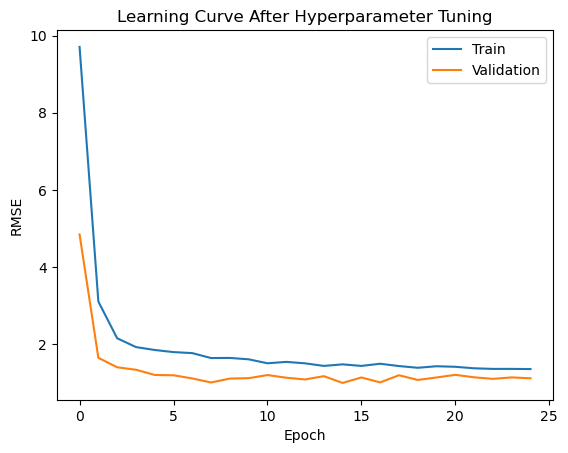

In [23]:
best = results_df.iloc[0]

model = Sequential([
    Input(shape=(X_train_processed.shape[1],)),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(
    optimizer=Adam(learning_rate=best['lr']),
    loss='mse',
    metrics=[tf.keras.metrics.RootMeanSquaredError(name='rmse')])

# Fit the model with the best parameters
history_best = model.fit(
    X_train_processed, y_train,
    validation_data=(X_val_processed, y_val),
    epochs=200,
    batch_size=int(best['batch_size']),
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=int(best['patience']), restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.000001)
    ],
    verbose=0
)

plt.plot(history_best.history['rmse'], label='Train')
plt.plot(history_best.history['val_rmse'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.title('Learning Curve After Hyperparameter Tuning')
plt.legend()
plt.show()

Both train and validation RMSE decrease smoothly without divergence, which is a clear improvement over the default model. 

However, the gap between train and validation persists throughout training, indicating that overfitting is reduced but not eliminated. The overall RMSE remains far above the baseline, confirming that hyperparameter tuning alone is not sufficient to close the gap between neural networks and classical regression methods on this dataset.

## Final Comparison

In [24]:
final_results = pd.DataFrame([
    {
        'Model': 'Lasso + Splines (baseline)',
        'Validation RMSE': BASELINE_LASSO_RESULTS['Validation RMSE'],
    },
    {
        'Model': 'Default NN (no tuning)',
        'Validation RMSE': best_val_rmse_baseline,
    },
    {
        'Model': 'NN + Random Search',
        'Validation RMSE': best['val_rmse'],
    },
])

final_results.style.format('{:.4f}', subset=['Validation RMSE']).hide(axis='index')

Model,Validation RMSE
Lasso + Splines (baseline),0.1150
Default NN (no tuning),0.7211
NN + Random Search,0.8110


Despite hyperparameter tuning, the neural network performs substantially worse than a tuned Lasso regression with splines, with a validation RMSE several times higher. 

## Conclusion

The results confirm that a feedforward neural network is not well-suited for this task. 
    
The default neural network (with no hyperparameter tuning) shows severe overfitting and high sensitivity to random initialization, while random search over training hyperparameters improves stability but not generalization.

> This project suggests that for small tabular datasets, simpler models may be a more reliable choice than neural networks. Further investigation with
larger datasets would be needed to draw broader conclusions.